In [18]:
import pandas as pd
import numpy as np
import datetime



In [24]:
df = pd.read_csv('myfxbookstatement.csv')
df = df.groupby('Close Date')[['Profit']].sum().sort_index().iloc[:-9]
df.index = pd.to_datetime(df.index)
df.sort_index(inplace=True)
df = df*1.26
macro = df.copy()
macro.columns = ['Profit Macro']

In [27]:
df.loc['2025'].sum()

Profit    13715.6292
dtype: float64

In [21]:
eq = pd.read_csv('equities_pnl.csv',index_col=0,parse_dates=True)
eq = eq[['Cumulative PNL']].diff().fillna(0)
eq.index = [datetime.datetime.strptime(dt, '%d/%m/%Y') for dt in eq.index]
eq.columns  = ['Profit EQ']
eq

,Profit EQ
2020-04-01,0.000000
2020-04-02,3.000000
2020-04-03,3.678786
2020-04-04,29.621543
2020-04-05,59.556079
...,...
2025-10-27,0.000000
2025-10-28,893.000000
2025-10-29,-1772.000000
2025-10-30,879.000000


In [22]:
df = pd.concat([macro,eq],axis = 1).fillna(0).loc['2025']
df['Profit Total'] = df.sum(axis=1)

<Axes: >

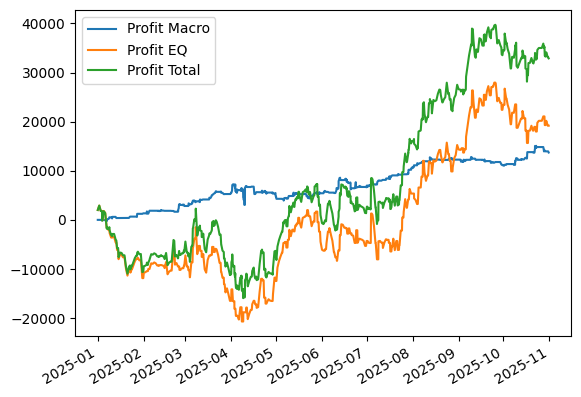

In [23]:
df.cumsum().plot()
#f.sum(axis =1).cumsum().plot(label = 'Total PnL')